Compute daily returns — daily_return = nav_t / nav_t-1 − 1 for all 40 schemes. Validate distribution looks reasonable.

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
5756     100016 2022-01-11  513.5542      0.005562
5757     100016 2022-01-12  512.3195     -0.002404
5758     100016 2022-01-13  510.2445     -0.004050
5759     100016 2022-01-14  514.3636      0.008073
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


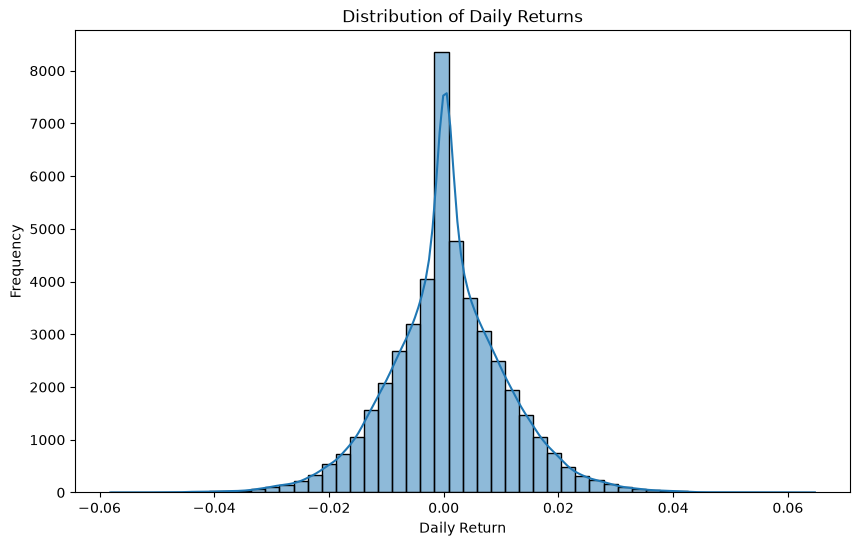

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load dataset
df = pd.read_csv("data/processed/02_nav_history_clean.csv")

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Sort values
df = df.sort_values(["amfi_code", "date"])

df["daily_return"] = (
    df.groupby("amfi_code")["nav"]
      .pct_change()
)

print(df.head(10))

# Validate Distribution
print(df["daily_return"].describe())

# Histogram
plt.figure(figsize=(10,6))

sns.histplot(
    df["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()



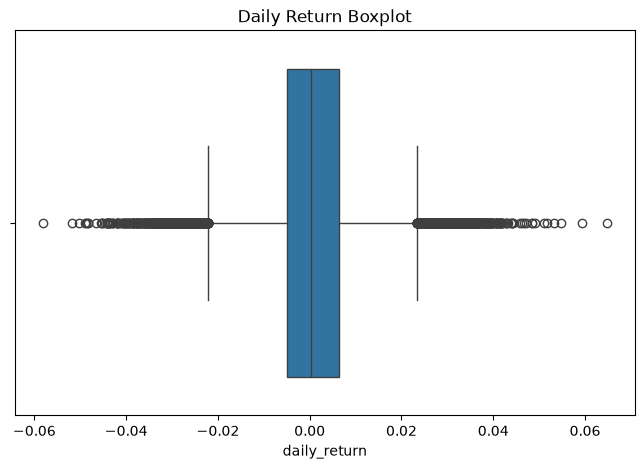

In [9]:
#Box Plot
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["daily_return"]
)

plt.title("Daily Return Boxplot")

plt.show()

In [17]:
# Save output

import os

os.makedirs("Day_04/reports", exist_ok=True)
df.to_csv(
    "reports/daily_returns.csv",
    index=False
)

print("Daily returns saved successfully.")

Daily returns saved successfully.


Compute CAGR for 1yr, 3yr, 5yr — CAGR = (NAV_end / NAV_start) ^ (1/n) − 1. Build a comparison table across all funds

In [16]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("data/processed/02_nav_history_clean.csv")

# Convert date
df["date"] = pd.to_datetime(df["date"])

# Sort data
df = df.sort_values(["amfi_code", "date"])

#function 
def calculate_cagr(nav_start, nav_end, years):
    return (nav_end / nav_start) ** (1 / years) - 1

#cal CAGR for all funds 
results = []

for fund in df["amfi_code"].unique():

    temp = df[df["amfi_code"] == fund].sort_values("date")

    if len(temp) < 2:
        continue

    nav_start = temp.iloc[0]["nav"]
    nav_end = temp.iloc[-1]["nav"]

    years = (temp.iloc[-1]["date"] - temp.iloc[0]["date"]).days / 365.25

    cagr = calculate_cagr(nav_start, nav_end, years)

    results.append({
        "amfi_code": fund,
        "start_nav": nav_start,
        "end_nav": nav_end,
        "years": round(years,2),
        "cagr": round(cagr*100,2)
    })

# comparison table
cagr_df = pd.DataFrame(results)

cagr_df = cagr_df.sort_values(
    "cagr",
    ascending=False
)

print(cagr_df.head())


import os

os.makedirs("Day_04/reports", exist_ok=True)

cagr_df.to_csv(
    "reports/cagr_table.csv",
    index=False
)

print("CAGR table saved successfully.")

    amfi_code  start_nav   end_nav  years   cagr
25     120505   135.8720  473.7640    4.4  32.83
21     119598    89.8738  309.2050    4.4  32.42
39     149324    81.6814  279.7511    4.4  32.29
36     148569    28.8620   97.7435    4.4  31.95
34     148567    70.2514  230.2708    4.4  30.97
CAGR table saved successfully.


Sharpe Ratio — (Rp − Rf) / Std(Rp) × √252. Use Rf = 6.5% (RBI repo rate proxy). Rank all 40 funds.

In [21]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("reports/daily_returns.csv")

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Sort data
df = df.sort_values(["amfi_code", "date"])

# Create daily_return column if it does not exist
if "daily_return" not in df.columns:
    df["daily_return"] = (
        df.groupby("amfi_code")["nav"]
          .pct_change()
    )

# Risk-free rate (Annual)
risk_free_rate = 0.065

# Convert annual risk-free rate to daily
daily_rf = risk_free_rate / 252

results = []

# Calculate Sharpe Ratio for each fund
for fund in df["amfi_code"].unique():

    temp = df[df["amfi_code"] == fund]

    returns = temp["daily_return"].dropna()

    if len(returns) < 2:
        continue

    avg_return = returns.mean()
    std_return = returns.std()

    if std_return == 0:
        continue

    sharpe = ((avg_return - daily_rf) / std_return) * np.sqrt(252)

    results.append({
        "amfi_code": fund,
        "average_return": round(avg_return, 6),
        "std_return": round(std_return, 6),
        "sharpe_ratio": round(sharpe, 4)
    })

# Create DataFrame
sharpe_df = pd.DataFrame(results)

# Ranking
sharpe_df = sharpe_df.sort_values(
    by="sharpe_ratio",
    ascending=False
).reset_index(drop=True)

sharpe_df["Rank"] = sharpe_df.index + 1

print(sharpe_df.head(10))


# Save File 

import os

os.makedirs("reports", exist_ok=True)

sharpe_df.to_csv("reports/sharpe_ratio.csv", index=False)

print("Sharpe Ratio saved successfully.")

   amfi_code  average_return  std_return  sharpe_ratio  Rank
0     148567        0.001074    0.008941        1.4483     1
1     120843        0.001082    0.010008        1.3067     2
2     148569        0.001124    0.011134        1.2349     3
3     119551        0.000917    0.008656        1.2083     4
4     120505        0.001161    0.012152        1.1801     5
5     149323        0.001055    0.011179        1.1321     6
6     100033        0.001080    0.011929        1.0937     7
7     118632        0.000865    0.008913        1.0817     8
8     101206        0.000852    0.009177        1.0272     9
9     120504        0.000843    0.009048        1.0265    10
Sharpe Ratio saved successfully.


Sortino Ratio — same formula but denominator uses only downside standard deviation (negative return days only).


Top 10 Funds by Sortino Ratio

   amfi_code  average_return  downside_std  sortino_ratio  Rank
0     148567        0.001074      0.005428         2.3856     1
1     120843        0.001082      0.005531         2.3643     2
2     148569        0.001124      0.006404         2.1469     3
3     119551        0.000917      0.004887         2.1403     4
4     120505        0.001161      0.007067         2.0294     5
5     149323        0.001055      0.006750         1.8751     6
6     118632        0.000865      0.005211         1.8501     7
7     100033        0.001080      0.007133         1.8291     8
8     120504        0.000843      0.005145         1.8053     9
9     101206        0.000852      0.005238         1.7996    10

CSV Saved Successfully!


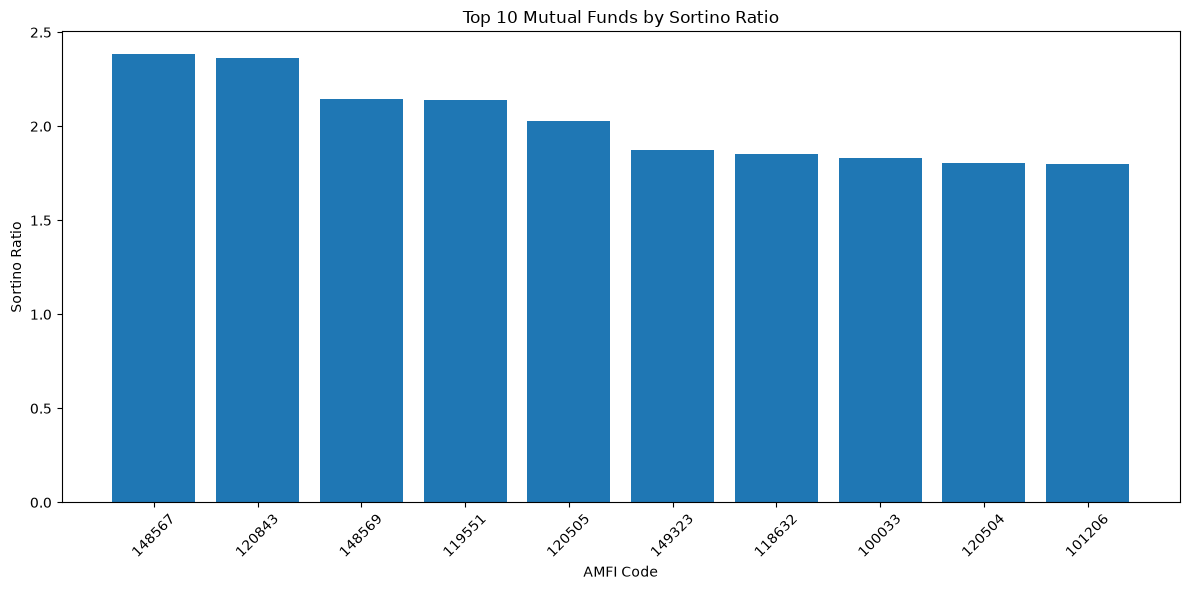


Chart Saved Successfully!


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Load Dataset

df = pd.read_csv("data/processed/02_nav_history_clean.csv")

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Sort data
df = df.sort_values(["amfi_code", "date"])

# Calculate Daily Returns

df["daily_return"] = (
    df.groupby("amfi_code")["nav"]
      .pct_change()
)


# Risk Free Rate

risk_free_rate = 0.065          # Annual (6.5%)

daily_rf = risk_free_rate / 252


# Calculate Sortino Ratio

results = []

for fund in df["amfi_code"].unique():

    temp = df[df["amfi_code"] == fund].copy()

    returns = temp["daily_return"].dropna()

    
    if len(returns) < 2:
        continue

    # Mean Return
    avg_return = returns.mean()

    # Downside Returns
    downside_returns = returns[returns < 0]

    if len(downside_returns) < 2:
        continue

    # Downside Standard Deviation
    downside_std = downside_returns.std()

    if downside_std == 0:
        continue

    # Sortino Ratio
    sortino = ((avg_return - daily_rf) / downside_std) * np.sqrt(252)

    results.append({

        "amfi_code": fund,

        "average_return": round(avg_return,6),

        "downside_std": round(downside_std,6),

        "sortino_ratio": round(sortino,4)

    })


# Create DataFrame

sortino_df = pd.DataFrame(results)

# Rank Funds
sortino_df = sortino_df.sort_values(
    by="sortino_ratio",
    ascending=False
).reset_index(drop=True)

sortino_df["Rank"] = sortino_df.index + 1


print("\nTop 10 Funds by Sortino Ratio\n")

print(sortino_df.head(10))


# Create Reports Folder

os.makedirs("reports", exist_ok=True)

# Save CSV

sortino_df.to_csv(
    "reports/sortino_ratio.csv",
    index=False
)

print("\nCSV Saved Successfully!")

# Plot
top10 = sortino_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["sortino_ratio"]
)

plt.title("Top 10 Mutual Funds by Sortino Ratio")

plt.xlabel("AMFI Code")

plt.ylabel("Sortino Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

os.makedirs("charts", exist_ok=True)

plt.savefig(
    "charts/sortino_ratio.png",
    dpi=300
)

plt.show()

print("\nChart Saved Successfully!")

Alpha and Beta — OLS regression of fund returns on Nifty 100 returns using scipy.stats.linregress. Alpha = intercept × 252.

Merged Shape : (46000, 5)
   amfi_code     alpha    beta  r_squared
0     100016  0.037476 -0.0583     0.0027
1     100025  0.042818  0.0012     0.0000
2     100033  0.271954  0.0051     0.0000
3     101206  0.213998  0.0211     0.0003
4     101207  0.108971 -0.0653     0.0011
Alpha Beta Completed


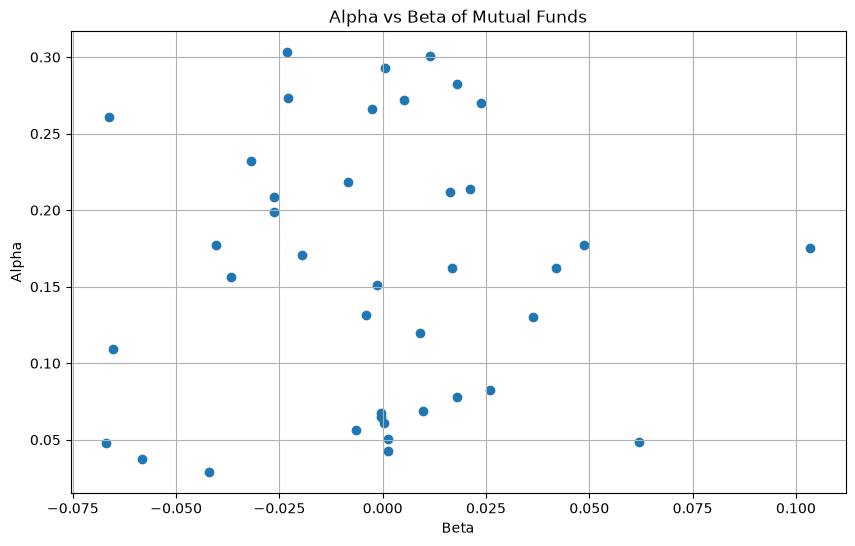

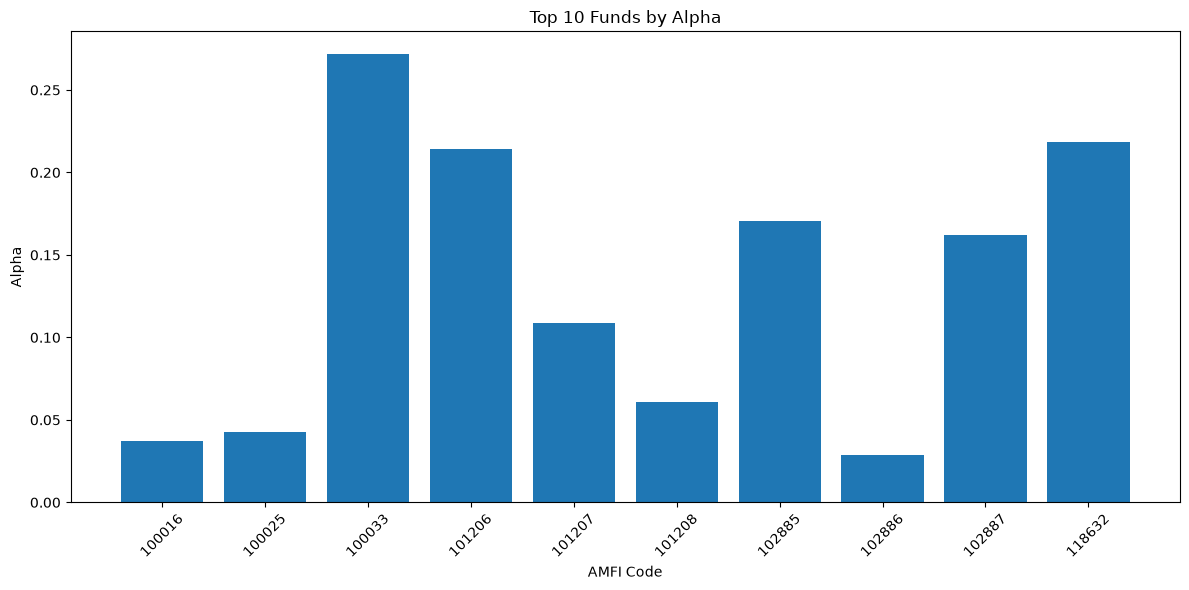

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import os


# Load Datasets

fund_df = pd.read_csv("data/processed/02_nav_history_clean.csv")
benchmark_df = pd.read_csv("data/processed/10_benchmark_indices_clean.csv")


# Convert Date


fund_df["date"] = pd.to_datetime(fund_df["date"])
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])


# Select NIFTY100


benchmark_df = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()


# Sort


fund_df = fund_df.sort_values(["amfi_code", "date"])
benchmark_df = benchmark_df.sort_values("date")


# Fund Daily Return


fund_df["daily_return"] = (
    fund_df.groupby("amfi_code")["nav"]
    .pct_change()
)


# Benchmark Daily Return


benchmark_df["benchmark_return"] = (
    benchmark_df["close_value"]
    .pct_change()
)


# Merge


merged = pd.merge(
    fund_df,
    benchmark_df[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

print("Merged Shape :", merged.shape)


# Alpha Beta


results = []

for fund in merged["amfi_code"].unique():

    temp = merged[
        merged["amfi_code"] == fund
    ].copy()

    temp = temp.dropna(
        subset=["daily_return", "benchmark_return"]
    )

    if len(temp) < 30:
        continue

    regression = linregress(
        temp["benchmark_return"],
        temp["daily_return"]
    )

    beta = regression.slope
    alpha = regression.intercept * 252

    results.append({

        "amfi_code": fund,
        "alpha": round(alpha,6),
        "beta": round(beta,4),
        "r_squared": round(regression.rvalue**2,4)

    })


# Create DataFrame


alpha_beta_df = pd.DataFrame(results)

print(alpha_beta_df.head())


# Save


os.makedirs("reports", exist_ok=True)

alpha_beta_df.to_csv(
    "reports/alpha_beta.csv",
    index=False
)

print("Alpha Beta Completed")



# Alpha vs beta Scattor plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(alpha_beta_df["beta"], alpha_beta_df["alpha"])

plt.xlabel("Beta")
plt.ylabel("Alpha")
plt.title("Alpha vs Beta of Mutual Funds")



plt.grid(True)

plt.savefig("charts/alpha_beta_scatter.png", dpi=300)

plt.show()



# top 10 fund by alpha 
top10 = alpha_beta_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(top10["amfi_code"].astype(str), top10["alpha"])

plt.xticks(rotation=45)

plt.xlabel("AMFI Code")
plt.ylabel("Alpha")

plt.title("Top 10 Funds by Alpha")

plt.tight_layout()

plt.savefig("charts/top10_alpha.png", dpi=300)

plt.show()

Maximum Drawdown — min(NAV / running_max − 1) for each fund. Find worst drawdown date range.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


# Load Dataset


df = pd.read_csv("data/processed/02_nav_history_clean.csv")

# Date Conversion
df["date"] = pd.to_datetime(df["date"])

# Sort
df = df.sort_values(["amfi_code","date"])


# Maximum Drawdown


results = []

for fund in df["amfi_code"].unique():

    temp = df[df["amfi_code"]==fund].copy()

    # Running Maximum NAV
    temp["running_max"] = temp["nav"].cummax()

    # Drawdown
    temp["drawdown"] = temp["nav"] / temp["running_max"] - 1

    # Maximum Drawdown
    max_dd = temp["drawdown"].min()

    # Worst Date
    worst_date = temp.loc[
        temp["drawdown"].idxmin(),
        "date"
    ]

    # Peak Date before drawdown
    peak_date = temp.loc[
        temp["nav"].idxmax(),
        "date"
    ]

    results.append({

        "amfi_code":fund,

        "maximum_drawdown":round(max_dd,4),

        "peak_date":peak_date,

        "worst_drawdown_date":worst_date

    })


# DataFrame


drawdown_df = pd.DataFrame(results)

drawdown_df = drawdown_df.sort_values(
    "maximum_drawdown"
)

print(drawdown_df.head(10))


# Save CSV


os.makedirs("reports",exist_ok=True)

drawdown_df.to_csv(
    "reports/drawdown.csv",
    index=False
)

print("Drawdown CSV Saved Successfully")

    amfi_code  maximum_drawdown  peak_date worst_drawdown_date
22     119599           -0.5257 2023-01-17          2025-10-28
17     119095           -0.5168 2025-05-22          2026-05-11
4      101207           -0.3545 2024-11-21          2026-05-11
39     149324           -0.3117 2026-04-24          2025-01-03
21     119598           -0.2871 2026-05-22          2025-05-14
7      102886           -0.2800 2025-01-07          2026-04-27
0      100016           -0.2473 2024-06-14          2022-09-15
29     120842           -0.2400 2025-10-22          2024-10-17
11     118634           -0.2334 2026-05-08          2026-02-20
15     119093           -0.2175 2025-12-02          2023-05-22
Drawdown CSV Saved Successfully


Fund Scorecard (0–100) — composite: 30% × 3yr return rank + 25% × Sharpe rank + 20% × Alpha rank + 15% × expense ratio rank (inverse) + 10% × max DD rank (inverse).


Index(['amfi_code', 'start_nav', 'end_nav', 'years', 'cagr'], dtype='str')
Index(['amfi_code', 'average_return', 'std_return', 'sharpe_ratio', 'Rank'], dtype='str')
Index(['amfi_code', 'alpha', 'beta', 'r_squared'], dtype='str')
Index(['amfi_code', 'maximum_drawdown', 'peak_date', 'worst_drawdown_date'], dtype='str')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')
   amfi_code  cagr  sharpe_ratio     alpha  maximum_drawdown  \
0     102886  1.17       -0.2058  0.028969           -0.2800   
1     100016  2.64       -0.2015  0.037476           -0.2473   
2     119095  1.52       -0.0760  0.048016           -0.5168   
3     119599  2.05       -0.0572  0.048824           -0.5257   
4     1190

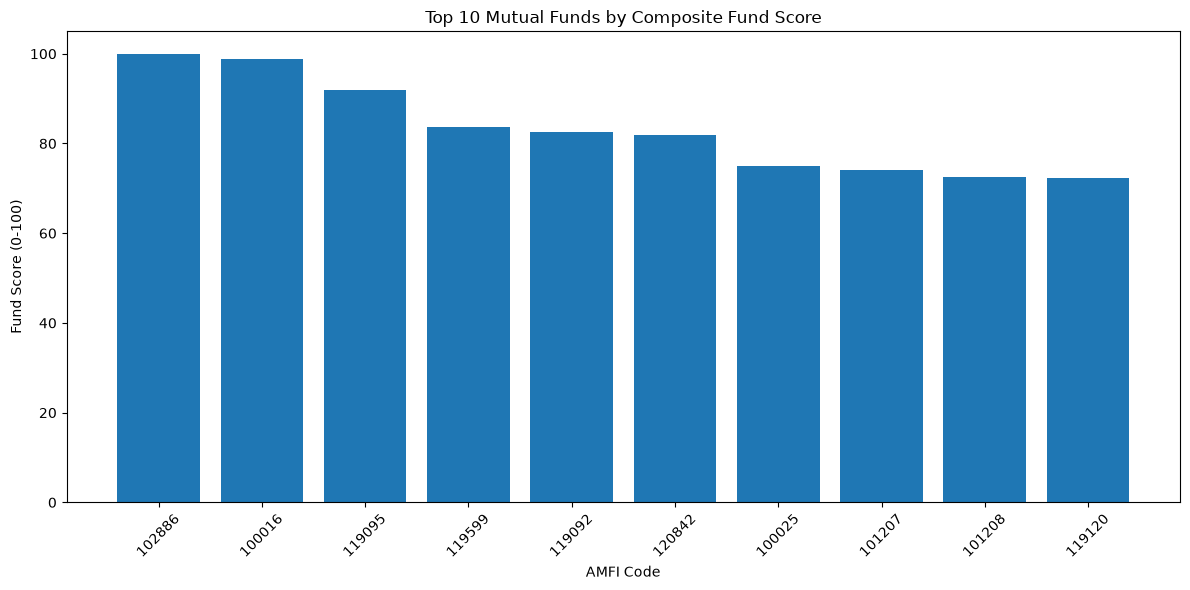

Chart Saved Successfully


In [ ]:
import pandas as pd

print(pd.read_csv("reports/cagr_table.csv").columns)
print(pd.read_csv("reports/sharpe_ratio.csv").columns)
print(pd.read_csv("reports/alpha_beta.csv").columns)
print(pd.read_csv("reports/drawdown.csv").columns)
print(pd.read_csv("data/processed/07_scheme_performance_clean.csv").columns)



import pandas as pd
import matplotlib.pyplot as plt
import os


# Load Reports


cagr = pd.read_csv("reports/cagr_table.csv")
sharpe = pd.read_csv("reports/sharpe_ratio.csv")
alpha = pd.read_csv("reports/alpha_beta.csv")
drawdown = pd.read_csv("reports/drawdown.csv")
expense = pd.read_csv("data/processed/07_scheme_performance_clean.csv")


#  Required Columns


cagr = cagr[["amfi_code", "cagr"]]

sharpe = sharpe[[
    "amfi_code",
    "sharpe_ratio"
]]

alpha = alpha[[
    "amfi_code",
    "alpha"
]]

drawdown = drawdown[[
    "amfi_code",
    "maximum_drawdown"
]]

expense = expense[[
    "amfi_code",
    "expense_ratio_pct"
]]

# Merge All Datasets


scorecard = cagr.merge(
    sharpe,
    on="amfi_code",
    how="inner"
)

scorecard = scorecard.merge(
    alpha,
    on="amfi_code",
    how="inner"
)

scorecard = scorecard.merge(
    drawdown,
    on="amfi_code",
    how="inner"
)

scorecard = scorecard.merge(
    expense,
    on="amfi_code",
    how="inner"
)


# Ranking,Higher

scorecard["return_rank"] = scorecard["cagr"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False
)

# Lower 
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

# Maximum Drawdown is negative.
# Less negative = Better
scorecard["drawdown_rank"] = scorecard["maximum_drawdown"].rank(
    ascending=False
)


# Composite Score


scorecard["Fund_Score"] = (

30 * scorecard["return_rank"]

+25 * scorecard["sharpe_rank"]

+20 * scorecard["alpha_rank"]

+15 * scorecard["expense_rank"]

+10 * scorecard["drawdown_rank"]

)/100


# Normalize Score (0–100)

scorecard["Fund_Score"] = (

100 *

(scorecard["Fund_Score"]-scorecard["Fund_Score"].min())/(scorecard["Fund_Score"].max()-scorecard["Fund_Score"].min()))


# Overall Rank

scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
).reset_index(drop=True)

scorecard["Overall_Rank"] = scorecard.index + 1

print(scorecard.head(10))

# Save CSV


os.makedirs("reports", exist_ok=True)

scorecard.to_csv(
    "reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved Successfully")


# Plot Top 10 Funds

top10 = scorecard.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Fund_Score"]
)

plt.title("Top 10 Mutual Funds by Composite Fund Score")

plt.xlabel("AMFI Code")

plt.ylabel("Fund Score (0-100)")

plt.xticks(rotation=45)

plt.tight_layout()

os.makedirs("charts", exist_ok=True)

plt.savefig(
    "charts/fund_scorecard.png",
    dpi=300
)

plt.show()

print("Chart Saved Successfully")

Benchmark comparison chart — plot top 5 funds vs Nifty 50 and Nifty 100 over 3 years. Compute tracking error = std(fund_return − benchmark_return) × √252.

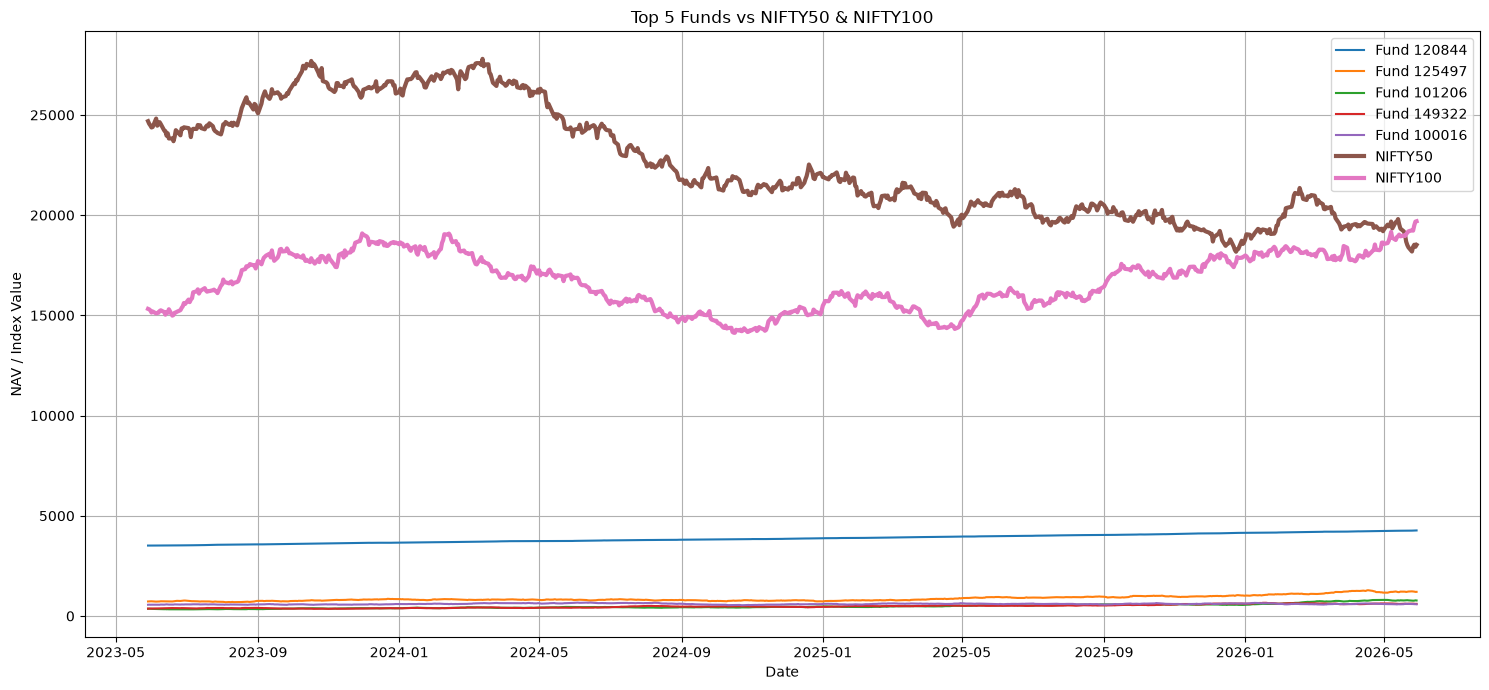

   amfi_code  tracking_error
0     120844        0.128095
1     125497        0.191564
2     101206        0.188911
3     149322        0.193719
4     100016        0.195404
Benchmark Comparison Completed


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


# Load Data

fund_df = pd.read_csv("data/processed/02_nav_history_clean.csv")
benchmark_df = pd.read_csv("data/processed/10_benchmark_indices_clean.csv")


# Date

fund_df["date"] = pd.to_datetime(fund_df["date"])
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

# Last 3 Years

latest = fund_df["date"].max()

start_date = latest - pd.DateOffset(years=3)

fund_df = fund_df[fund_df["date"] >= start_date]

benchmark_df = benchmark_df[
    benchmark_df["date"] >= start_date
]

# Daily Return

fund_df = fund_df.sort_values(
    ["amfi_code","date"]
)

fund_df["daily_return"] = (
    fund_df.groupby("amfi_code")["nav"]
    .pct_change()
)

benchmark_df = benchmark_df.sort_values(
    ["index_name","date"]
)

benchmark_df["benchmark_return"] = (
    benchmark_df.groupby("index_name")["close_value"]
    .pct_change()
)

# Top 5 Funds (Highest CAGR)


top5 = (
    fund_df.groupby("amfi_code")["nav"]
    .last()
    .sort_values(ascending=False)
    .head(5)
    .index
)

fund_top = fund_df[
    fund_df["amfi_code"].isin(top5)
]


# Plot

plt.figure(figsize=(15,7))

for fund in top5:

    temp = fund_top[
        fund_top["amfi_code"]==fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=f"Fund {fund}"
    )

# NIFTY50

n50 = benchmark_df[
    benchmark_df["index_name"]=="NIFTY50"
]

plt.plot(
    n50["date"],
    n50["close_value"],
    linewidth=3,
    label="NIFTY50"
)

# NIFTY100

n100 = benchmark_df[
    benchmark_df["index_name"]=="NIFTY100"
]

plt.plot(
    n100["date"],
    n100["close_value"],
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")

plt.xlabel("Date")

plt.ylabel("NAV / Index Value")

plt.legend()

plt.grid(True)

plt.tight_layout()

os.makedirs("charts",exist_ok=True)

plt.savefig(
    "charts/benchmark_comparison.png",
    dpi=300
)

plt.show()


# Tracking Error


tracking=[]

benchmark=n100[
    ["date","benchmark_return"]
]

for fund in top5:

    temp=fund_df[
        fund_df["amfi_code"]==fund
    ][["date","daily_return"]]

    merge=pd.merge(
        temp,
        benchmark,
        on="date",
        how="inner"
    )

    merge=merge.dropna()

    tracking_error=(
        (
        merge["daily_return"]
        -
        merge["benchmark_return"]
        ).std()
    )*np.sqrt(252)

    tracking.append({

        "amfi_code":fund,

        "tracking_error":round(
            tracking_error,
            6
        )

    })

tracking_df=pd.DataFrame(tracking)

print(tracking_df)

tracking_df.to_csv(
    "reports/tracking_error.csv",
    index=False
)

print("Benchmark Comparison Completed")